In [1]:
import os
if os.getcwd()[-11:] == "exploration":
    os.chdir('..')
import data.involcan.pull

### Find sensors of interest

In [2]:
import pandas as pd

files = pd.read_csv("data/involcan/metadata/available_files.csv")

In [3]:
# from datetime import datetime
starttime = pd.Timestamp('2021-09-12', tz='UTC')
endtime = pd.Timestamp('2021-09-26', tz='UTC')

files['start_time'] = pd.to_datetime(files['start_time'], utc=True)
files['end_time'] = pd.to_datetime(files['end_time'], utc=True)


eruption_files = files[(files['start_time']==starttime) | (files['end_time']==endtime) ]
eruption_sensors = pd.unique(eruption_files['sensor']).tolist()

In [4]:
print(f"There were {len(eruption_sensors)} measuring during the eruption")
print(f"They were: \n {eruption_sensors}")

There were 18 measuring during the eruption
They were: 
 ['PGAR', 'PBBA', 'PPMA', 'PMLU', 'PLPI', 'PTAB', 'PCOR', 'PA03', 'PA00', 'PA05', 'PA09', 'PA01', 'PA04', 'PA02', 'PA08', 'PA06', 'PA07', 'PSAB']


In [5]:
sensors = pd.read_csv("data/involcan/metadata/stations_all.dat", sep=r"\s+",names=["station", "lat", "lon", "height"])
sensors_lp = sensors[
    ((sensors['lat']<28.871164) & (sensors['lat']>28.437932)) &
    ((sensors['lon']<-17.666590) & (sensors['lon']>-18.039439))
]


In [6]:
from shapely.geometry import Point, Polygon

polygon_coords = [[-18.043671,28.436091],[-18.043671,28.879552],
                  [-17.704468,28.879552],[-17.704468,28.436091],]
polygon = Polygon(polygon_coords)

point = Point(-17.888489,28.694202)
polygon.contains(point)

def is_inside(row, polygon):
    point = Point(row['lon'], row['lat'])  # Importante: (x, y) = (lon, lat)
    return polygon.contains(point)

sensors_lp = sensors[sensors.apply(is_inside, axis=1, args = (polygon,))]

### Download the files of interest

In [7]:
from datetime import datetime, timedelta
starttime = datetime(2021, 9, 15)
endtime = datetime(2021, 9, 20)
# endtime = datetime(2021, 12, 14)
data_path = "/SCRATCH/TIC270/gsus/data/involcan/mseed/eruption/"
channels = ["HHE", "HHN", "HHZ"]
# channels = ["HHE"]
sensors = eruption_sensors

# data.involcan.pull.download_files(starttime, endtime, sensors, channels, data_path, user='seiscomp', verbose=True);

#### Discarded sensors:
- PGAR: File missing data
- PBBA: File missing data
- PA03: Missing data before the 18th of september
- PA00: Missing data before the 19th of september
- PA05: Missing data in the period of interest
- PA09: Missing data in the period of interest
- PA01: Missing data in the period of interest
- PA04: Missing data in the period of interest
- PA02: Missing data in the period of interest
- PA08: Missing data in the period of interest
- PA06: Missing data in the period of interest
- PA07: Missing data in the period of interest
- PSAB: No data in the period of interest


### Analyze the data

Reading 2021 data for sensor PPMA...


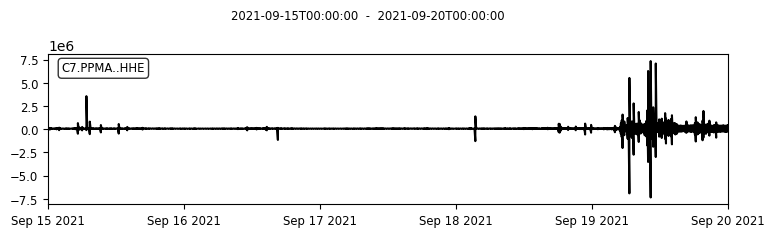

Reading 2021 data for sensor PMLU...


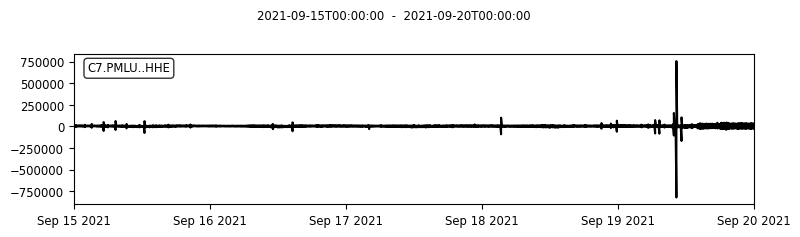

Reading 2021 data for sensor PLPI...


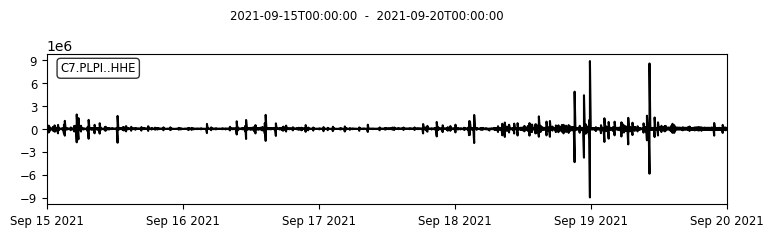

Reading 2021 data for sensor PTAB...


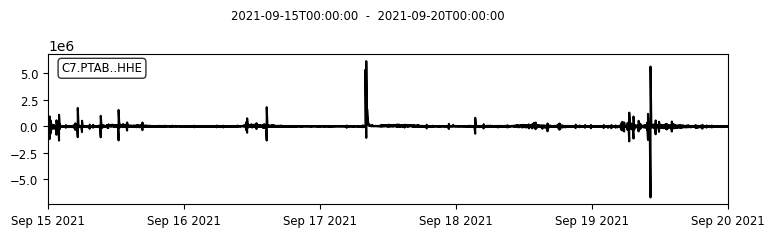

Reading 2021 data for sensor PCOR...


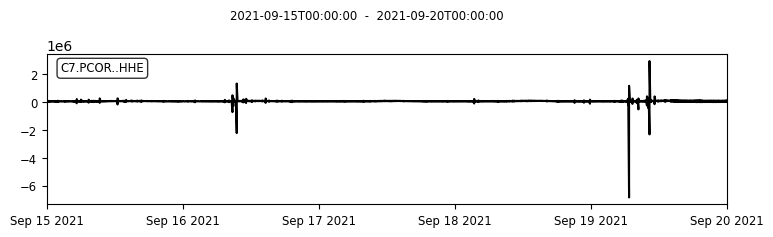

In [8]:
import obspy
from obspy.core import UTCDateTime
import numpy as np


ST = []
sensors = ['PPMA', 'PMLU', 'PLPI', 'PTAB','PCOR']
# sensors = ['PPMA', 'PLPI']

sensor_ids = [eruption_sensors.index(element) for element in sensors if element in eruption_sensors]

for sensor_id in sensor_ids:
    print(f"Reading 2021 data for sensor {eruption_sensors[sensor_id]}...")
    st = obspy.read(f"{data_path}/C7.{eruption_sensors[sensor_id]}.*.HHE.*.2021.*",
                    starttime=UTCDateTime(starttime), endtime=UTCDateTime(endtime))
    st.merge()
    st.plot();
    ST.append(st)



#### Eliminate calibration pulses

In [9]:
pulses = []
# PPMA pulses:
pulses.append([UTCDateTime(datetime(2021,9,16,16,33,30)), UTCDateTime(datetime(2021,9,16,16, 36,30))])
# st.plot(starttime=UTCDateTime(datetime(2021,9,16,16, 33,30)), endtime=UTCDateTime(datetime(2021,9,16,16, 36,30)));

pulses.append([UTCDateTime(datetime(2021,9,15,6, 51,0)), UTCDateTime(datetime(2021,9,15,6,54,30))])
# st.plot(starttime=UTCDateTime(datetime(2021,9,15,6, 51,0)), endtime=UTCDateTime(datetime(2021,9,15,6,54,30)));



#### Analyze frequencies with MESA

In [10]:
from msa.feature_extraction import features
from msa.visualization import plot

In [11]:
sr = st[0].stats.sampling_rate

window_length = 20 # s
window_samples = int(window_length*sr)
# shift = window_length*1000 #s
shift = 3600 #s
hop = int(shift*sr)

M = len(sensor_ids)
N = len(sensor_ids)
times = [[] for _ in range(M)]
freqs = [[] for _ in range(M)]
Sxxs  = [[] for _ in range(M)]

for i, sensor_id in enumerate(sensor_ids):

    signal = ST[i][0].data
    time, freq, Sxx = features.spectrogram(signal, sr, window_samples, hop, "blackman", "zeros", "linear",)
    times[i] = time[1:]
    freqs[i] = freq
    Sxxs[i]  = Sxx[:,1:]

Sxxs = np.array(Sxxs)
freqs = np.array(freqs)
times = np.array(times)

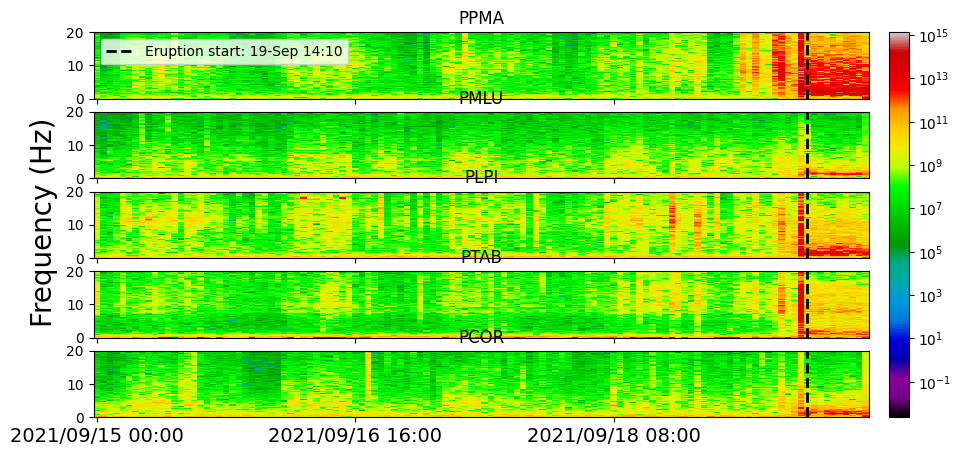

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# timeUTC = np.linspace(starttime, endtime, num= len(times), endpoint=False, dtype='datetime64[s]')#.astype("datetime64[m]")
timeUTC = np.arange(starttime, endtime, timedelta(seconds=shift), dtype='datetime64[s]')#.astype("datetime64[m]")

target_time = np.datetime64(datetime(2021, 9, 19, 14, 10), 'm')
eruption_idx = np.argmin(np.abs(timeUTC - target_time))

fig, ax = plt.subplots(M,1, figsize=(10,5), sharex=True)

vmin = np.min(Sxxs)
vmax = np.max(Sxxs)

if type(ax) != np.ndarray: ax = [ax]

skip:int = len(times[0])//3
locs = times[0][0::skip]
timeUTC_label = timeUTC[0::skip]
date_formatter = mdates.DateFormatter('%Y/%m/%d %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]

for i, sensor_id in enumerate(sensor_ids):
    ax[i].set_title(f"{eruption_sensors[sensor_id]}")
    _,_, mesh = plot.spectrogram(times[i], freqs[i], Sxxs[i], cmap="nipy_spectral",
                                 logscale=True, ax = ax[i], vmin=vmin, vmax = vmax, ylim=(0,20));


    ax[i].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);

    ax[i].axvline(x=times[i][eruption_idx], color='black', linestyle='--', linewidth=2, label='Eruption start: 19-Sep 14:10')
    if i == 0: ax[i].legend();


bbox = ax[-1,].get_position()
tbox = ax[ 0,].get_position()
cax = fig.add_axes([0.92, bbox.y0, 0.02, tbox.y1-bbox.y0])
cbar = fig.colorbar(mesh, cax=cax,)

# ax.set_ylabel("Frequency (Hz)", fontsize=20)
fig.text(.075, 0.5, "Frequency (Hz)", ha='center', va='center', rotation=90, fontsize=20);

### PCA Visualizations

#### Normalization of the Sxxs tensor

### Preprocessing

In [13]:
Sxxs.shape, type(Sxxs.shape),times.shape
np.mean(Sxxs, 0).shape


Sxxs_norm = Sxxs
# Mean centering
Sxxs_norm = Sxxs_norm - np.mean(Sxxs_norm, 0)
# Min max scaling
# Sxxs_norm = (Sxxs_norm - np.min(Sxxs_norm, 0)) / (np.max(Sxxs_norm,0) - np.min(Sxxs_norm,0))
# Max scaling
Sxxs_norm = (Sxxs_norm) / (np.max(np.abs(Sxxs_norm),0))

vmin = np.min(Sxxs_norm)
vmax = np.max(Sxxs_norm)

vmin, vmax


(np.float64(-1.0), np.float64(1.0))

In [14]:
# Data fusion
X = np.vstack(Sxxs_norm).T
X.shape


(120, 5005)

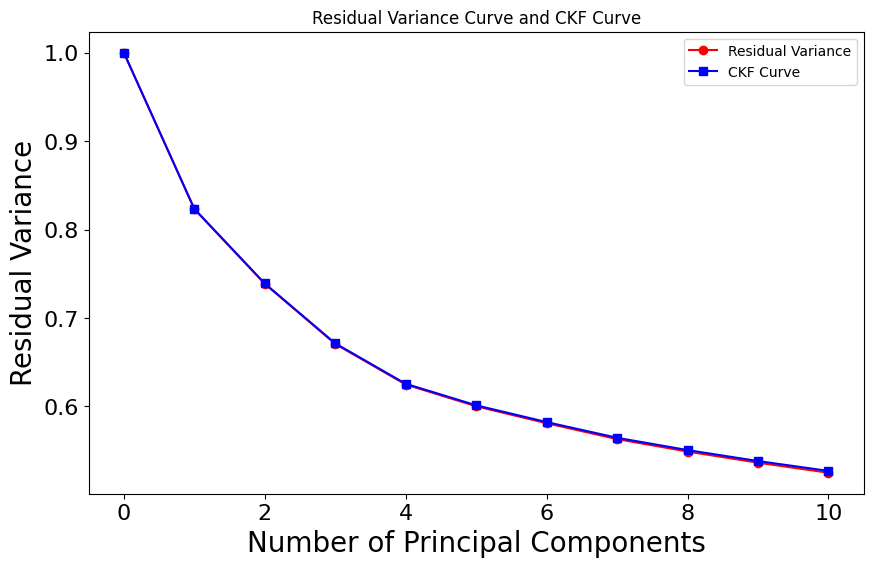

In [15]:
import mspc_pca.plot
mspc_pca.plot.var_pca(X, 10);

In [16]:
# !pip install scikit-learn

In [ ]:
from sklearn.decomposition import PCA
PCs=2
pca = PCA(n_components=PCs)


loadings_label = np.array([f"{round(x, 2)}Hz" for x in freqs[0]]*M) # Add for several sensors 
sensor_class = np.repeat(eruption_sensors, len(freqs[0]))
sensor_class = np.repeat(np.arange(0,M), len(freqs[0]))

time_class = np.hstack([np.repeat(1, eruption_idx-1),
                        np.repeat(2, len(times[0])-eruption_idx+1)])

fig, ax = plt.subplots(1,1, figsize=(9,6))

mspc_pca.plot.biplot(X, pca, 1, 2, timeUTC, np.array(loadings_label),0.09, time_class ,sensor_class, loading_percentile = +.5,
                     ax = ax );

ax.legend()


/home/TIC270/gsus/DigiVolcan/installation/miniconda3/envs/lafragua/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


In [ ]:
# Mask to see a specific sensor:
sensor = "PPMA"
sensor_id=0
mask = sensor_class == sensor_id

# X=aux
# X_cut = X[:,mask]
# aux = X
# X = X_cut

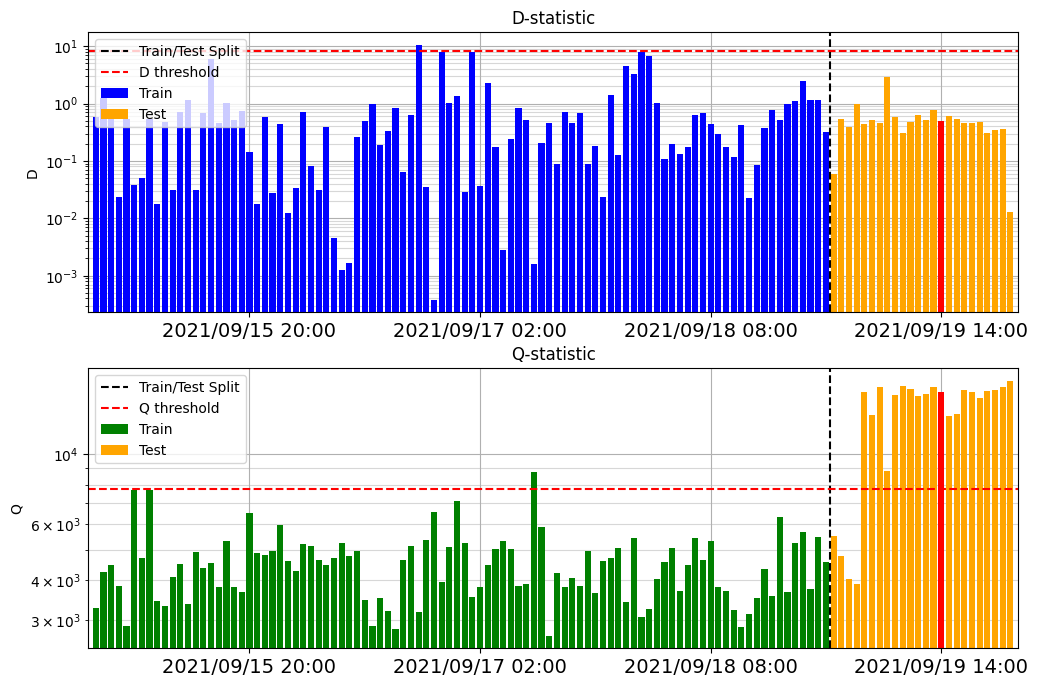

In [ ]:
import mspc_pca.mspc
PCs = 1


day_id = np.argmin(np.abs(timeUTC - np.datetime64(datetime(2021, 9, 19), 'm')))

D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q = mspc_pca.mspc.DQ_tt(X[:day_id], X[day_id:], PCs, percentile_threshold=True, alpha=0.01)

fig, ax = mspc_pca.mspc.plot_DQ_tt(D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q,
                                   logscale=True, event_index=[eruption_idx], 
                labels=None, plot_train=True, opacity=None, ax=None)


n_bars = len(Q_train)+len(Q_test)

skip:int = len(timeUTC)//4
start = 20
locs = np.arange(0, n_bars)[start::skip]
timeUTC_label = timeUTC[start::skip]



date_formatter = mdates.DateFormatter('%Y/%m/%d %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]
ax[0].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);
ax[1].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);

for axis in ax:
    axis.set_xlim(-1, n_bars)
    axis.grid(which='minor', alpha=0.5,)
    axis.set_axisbelow(True)